# Loading Data

## HPI Data

Monthly FHFA House Price Index® for Census Divisions and U.S.
Purchase-Only Index (Only Index available with Monthly Frequency)

NSA=Not Seasonally Adjusted; SA=Seasonally Adjusted

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
hpi = pd.read_excel('hpi_po_monthly_hist.xls',index_col = 0)
hpi

,East North Central\n(NSA),East North Central\n(SA),East South Central\n(NSA),East South Central\n(SA),Middle Atlantic\n(NSA),Middle Atlantic\n(SA),Mountain\n\n(NSA),Mountain\n\n(SA),New England\n\n(NSA),New England\n\n(SA),Pacific\n\n(NSA),Pacific\n\n(SA),South Atlantic\n(NSA),South Atlantic\n(SA),West North Central\n(NSA),West North Central\n(SA),West South Central\n(NSA),West South Central\n(SA),USA\n\n(NSA),USA\n\n(SA)
Month,,,,,,,,,,,,,,,,,,,,
1991-01-01,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1991-02-01,100.89,100.94,100.99,100.63,100.15,100.32,98.39,98.75,101.77,102.38,100.13,100.57,100.58,100.47,100.49,100.45,99.82,99.59,100.39,100.45
1991-03-01,101.30,100.90,100.85,100.43,100.10,99.82,100.21,100.63,101.52,101.36,99.96,100.13,101.00,100.60,100.43,100.13,100.62,100.49,100.68,100.48
1991-04-01,101.69,100.97,100.83,100.47,99.60,99.28,100.30,100.38,101.04,101.06,100.14,100.12,100.90,100.40,100.83,100.36,100.36,100.08,100.68,100.33
1991-05-01,102.30,101.32,101.14,100.76,99.72,99.24,100.70,100.49,99.83,99.85,100.34,100.10,100.77,100.46,100.80,100.32,100.76,100.27,100.84,100.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,349.27,347.84,397.02,394.53,379.82,378.97,600.88,596.00,419.41,416.68,468.20,464.30,461.03,456.82,402.85,400.50,423.07,422.01,426.05,423.15
2024-04-01,354.08,348.72,404.52,400.12,383.13,378.52,608.35,596.05,428.09,419.57,474.37,465.45,466.80,459.36,410.70,403.22,427.02,420.92,431.73,424.51
2024-05-01,360.18,350.44,404.35,398.18,388.16,379.14,612.11,597.06,429.97,419.75,475.07,464.82,469.42,459.68,413.00,401.90,429.26,420.38,434.84,424.65


## FNMA Loan-by-loan data

In [6]:
def read(address):
    chunksize = 100000  # 每次读取的行数大小
    # 选择需要的列编号
    usecols = [9, 11, 1, 2, 7, 8, 12, 13, 14, 15, 16, 17, 19, 22, 23, 26, 29, 30]
    
    # 读取数据时只选择这些列
    chunks = pd.read_csv(address, sep='|', na_values=[''], usecols=usecols, chunksize=chunksize)
    
    # 合并所有读取的块
    df = pd.concat(chunks, ignore_index=True)

    new_column_names = ['Loan Identifier',  # 2
                        'Monthly Reporting Period',  # 3
                        'Original Interest Rate',  # 8
                        'Current Interest Rate',  # 9
                        'Original UPB', #10
                        'Current Actual UPB', #12
                        'Original Loan Term',  # 13
                        'Origination Date',  # 14
                        'First Payment Date',  # 15
                        'Loan Age',  # 16
                        'Remaining Months to Legal Maturity',  # 17
                        'Remaining Months To Maturity',  # 18
                        'Original LTV',  # 20
                        'Debt-To-Income (DTI)',  # 23
                        'FICO at Origination',  # 24
                        'Loan Purpose',  # 27
                        'Occupancy Status',  # 30
                        'Property State']  # 31
    
    # 重命名列
    df.columns = new_column_names
    
    print("读取成功")
    print(df.head())
    return df


In [7]:
def test_read(address):
    df = pd.read_csv(address, sep='|', dtype='str', na_values=[''], nrows=1000000)
    print("successfully read 1000000 rows")
    print(df.head())
    return df

2015Q1 Data

In [9]:
Q1_2015_0 = read('2015Q1.csv')

读取成功
   Loan Identifier  Monthly Reporting Period  Original Interest Rate  \
0     100002091588                     22015                   4.125   
1     100002091588                     32015                   4.125   
2     100002091588                     42015                   4.125   
3     100002091588                     52015                   4.125   
4     100002091588                     62015                   4.125   

   Current Interest Rate  Original UPB  Current Actual UPB  \
0                  4.125      345000.0                 0.0   
1                  4.125      345000.0                 0.0   
2                  4.125      345000.0                 0.0   
3                  4.125      345000.0                 0.0   
4                  4.125      345000.0                 0.0   

   Original Loan Term  Origination Date  First Payment Date  Loan Age  \
0                 360            122014               22015       1.0   
1                 360            122014    

In [10]:
Q1_2015 = Q1_2015_0.copy()
Q1_2015 = Q1_2015.apply(pd.to_numeric, errors='coerce')
Q1_2015['Monthly Reporting Period'] = pd.to_datetime(Q1_2015['Monthly Reporting Period'].astype(int).astype(str).str[-4:] + '-' + Q1_2015['Monthly Reporting Period'].astype(int).astype(str).str[0] + '-01')

2019Q2 Data

In [12]:
Q1_2019_0 = read('2019Q1.csv')

读取成功
   Loan Identifier  Monthly Reporting Period  Original Interest Rate  \
0     100000913397                     22019                   5.875   
1     100000913397                     32019                   5.875   
2     100000913397                     42019                   5.875   
3     100000913397                     52019                   5.875   
4     100000913397                     62019                   5.875   

   Current Interest Rate  Original UPB  Current Actual UPB  \
0                  5.875      324000.0                 0.0   
1                  5.875      324000.0                 0.0   
2                  5.875      324000.0                 0.0   
3                  5.875      324000.0                 0.0   
4                  5.875      324000.0                 0.0   

   Original Loan Term  Origination Date  First Payment Date  Loan Age  \
0                 360             92018              112018       4.0   
1                 360             92018    

## Weekly Mortgage Data

In [14]:
header_rows = pd.read_excel('historicalweeklydata.xlsx', header=None, nrows=3)

# take care of the comments in excel file (first 3 rows) and get a usable columns
new_header = header_rows.astype(str).agg(' '.join, axis=0)

# read the whole file
weelyloan = pd.read_excel('historicalweeklydata.xlsx', header=None, skiprows=3)

# rename columns
weelyloan.columns = new_header

weelyloan.head()

,nan nan Week,U.S. 30 yr FRM,30 yr fees & points,U.S. 15 yr FRM,15 yr fees & points,U.S. 5/1 ARM,5/1 ARM fees & points,U.S. 5/1 ARM margin,30 yr FRM/ 5/1 ARM spread
0,1971-04-02 00:00:00,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1971-04-09 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
2,1971-04-16 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
3,1971-04-23 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-30 00:00:00,7.29,,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
weelyloan.columns = ['Date'] + weelyloan.columns[1:].tolist()

weelyloan['Date'] = pd.to_datetime(weelyloan['Date'], errors='coerce')  # errors='coerce' 将处理无效日期

monthlyrate = (weelyloan.groupby(weelyloan['Date'].dt.to_period('M')).first().reset_index(drop=True)).iloc[:,:2]

# set Day in dates as 1
monthlyrate['Date'] = monthlyrate['Date'].apply(lambda x: x.replace(day=1) if pd.notnull(x) else x)

monthlyrate['rate_lag2'] = monthlyrate['U.S. 30 yr FRM'].shift(2)
# format it to timestamp
monthlyrate['Date'] = pd.to_datetime(monthlyrate['Date'])

monthlyrate

,Date,U.S. 30 yr FRM,rate_lag2
0,1971-04-01,7.33,NaN
1,1971-05-01,7.38,NaN
2,1971-06-01,7.52,7.33
3,1971-07-01,7.54,7.38
4,1971-08-01,7.66,7.52
...,...,...,...
638,2024-06-01,6.99,6.82
639,2024-07-01,6.95,7.22
640,2024-08-01,6.73,6.99
641,2024-09-01,6.35,6.95


## Macroecon Data

In [17]:
#rate = pd.read_excel('Macroecon.xls',sheet_name = 'Interest Rate')
unemployment = pd.read_excel('Macroecon.xls',sheet_name = 'Unemployment Rate')
income = pd.read_excel('Macroecon.xls',sheet_name = 'Income')

# Rate Refi (S Curve)
S curve by following characteristics:  
▪ X-axis incentive buckets:   
o <-100bps, -100 to -50bps, -50 to 0bps, 0 to 50bps, 50 to 100 bps, 100 to 150 bps, 150+ bps  
▪ Calculate and plot the SMM for each criteria (bucket by reasonable sample sizes):  
**o FICO, Loan Size(original loan balance), Occupancy type, Loan purpose, DTI, Geography (NY/FL/TX, other)**  
o Provide summary statistics and reasoning  
o Does the result make sense?

预测：针对criteria分组，然后画corr matrix，再用ML（暂时不用做）

**Calculate Monthly Interest Rate:**
$$
\text{Monthly Interest Rate} = \frac{\text{Original Interest Rate}}{12 \times 100}
$$

**Calculate the scheduled payment amount \( A \) using the installment repayment formula:**
$$
A = \frac{P \times \left( r \times (1 + r)^n \right)}{(1 + r)^n - 1}
$$
where:
- \( A \) is the scheduled payment amount
- \( P \) is the current actual unpaid principal balance (Current Actual UPB)
- \( r \) is the monthly interest rate (Monthly Interest Rate)
- \( n \) is the original loan term (Original Loan Term)

**Calculate the monthly interest portion:**
$$
\text{Interest Payment} = P \times r
$$

**Calculate the monthly principal portion:**
$$
\text{Scheduled Principal} = A - \text{Interest Payment}
$$


In [21]:
Q1_2015 = pd.merge(Q1_2015, monthlyrate, left_on='Monthly Reporting Period', right_on=monthlyrate.columns[0], how='left')
Q1_2015

,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,Remaining Months To Maturity,Original LTV,Debt-To-Income (DTI),FICO at Origination,Loan Purpose,Occupancy Status,Property State,Date,U.S. 30 yr FRM,rate_lag2
0,100002091588,2015-02-01,4.125,4.125,345000.0,0.00,360,122014,22015,1.0,...,359.0,95,32.0,652.0,NaN,NaN,NaN,2015-02-01,3.59,3.89
1,100002091588,2015-03-01,4.125,4.125,345000.0,0.00,360,122014,22015,2.0,...,358.0,95,32.0,652.0,NaN,NaN,NaN,2015-03-01,3.75,3.73
2,100002091588,2015-04-01,4.125,4.125,345000.0,0.00,360,122014,22015,3.0,...,357.0,95,32.0,652.0,NaN,NaN,NaN,2015-04-01,3.70,3.59
3,100002091588,2015-05-01,4.125,4.125,345000.0,0.00,360,122014,22015,4.0,...,356.0,95,32.0,652.0,NaN,NaN,NaN,2015-05-01,3.80,3.75
4,100002091588,2015-06-01,4.125,4.125,345000.0,0.00,360,122014,22015,5.0,...,355.0,95,32.0,652.0,NaN,NaN,NaN,2015-06-01,3.87,3.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27666098,999995696635,2017-02-01,4.500,4.500,150000.0,143835.36,360,12015,32015,24.0,...,333.0,92,43.0,775.0,NaN,NaN,NaN,2017-02-01,4.19,4.08
27666099,999995696635,2017-03-01,4.500,4.500,150000.0,143617.25,360,12015,32015,25.0,...,332.0,92,43.0,775.0,NaN,NaN,NaN,2017-03-01,4.10,4.20
27666100,999995696635,2017-04-01,4.500,4.500,150000.0,143617.25,360,12015,32015,26.0,...,332.0,92,43.0,775.0,NaN,NaN,NaN,2017-04-01,4.10,4.19
27666101,999995696635,2017-05-01,4.500,4.500,150000.0,143178.57,360,12015,32015,27.0,...,330.0,92,43.0,775.0,NaN,NaN,NaN,2017-05-01,4.02,4.10


In [22]:
# Calculate monthly rate with original rate, for scheduled interest calculating
Q1_2015['Monthly Interest Rate'] = Q1_2015['Original Interest Rate'] / 12 / 100

# Employ Amortization formula to calculate schedule
Q1_2015['Scheduled Payment'] = (Q1_2015['Original UPB'] *
                                (Q1_2015['Monthly Interest Rate'] * (1 + Q1_2015['Monthly Interest Rate']) ** Q1_2015['Original Loan Term']) /
                                ((1 + Q1_2015['Monthly Interest Rate']) ** Q1_2015['Original Loan Term'] - 1))

Q1_2015['Interest Payment'] = Q1_2015['Current Actual UPB']* Q1_2015['Monthly Interest Rate']
Q1_2015['Scheduled Principal'] = Q1_2015['Scheduled Payment'] - Q1_2015['Interest Payment']
Q1_2015

,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,Loan Purpose,Occupancy Status,Property State,Date,U.S. 30 yr FRM,rate_lag2,Monthly Interest Rate,Scheduled Payment,Interest Payment,Scheduled Principal
0,100002091588,2015-02-01,4.125,4.125,345000.0,0.00,360,122014,22015,1.0,...,NaN,NaN,NaN,2015-02-01,3.59,3.89,0.003438,1672.041577,0.000000,1672.041577
1,100002091588,2015-03-01,4.125,4.125,345000.0,0.00,360,122014,22015,2.0,...,NaN,NaN,NaN,2015-03-01,3.75,3.73,0.003438,1672.041577,0.000000,1672.041577
2,100002091588,2015-04-01,4.125,4.125,345000.0,0.00,360,122014,22015,3.0,...,NaN,NaN,NaN,2015-04-01,3.70,3.59,0.003438,1672.041577,0.000000,1672.041577
3,100002091588,2015-05-01,4.125,4.125,345000.0,0.00,360,122014,22015,4.0,...,NaN,NaN,NaN,2015-05-01,3.80,3.75,0.003438,1672.041577,0.000000,1672.041577
4,100002091588,2015-06-01,4.125,4.125,345000.0,0.00,360,122014,22015,5.0,...,NaN,NaN,NaN,2015-06-01,3.87,3.70,0.003438,1672.041577,0.000000,1672.041577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27666098,999995696635,2017-02-01,4.500,4.500,150000.0,143835.36,360,12015,32015,24.0,...,NaN,NaN,NaN,2017-02-01,4.19,4.08,0.003750,760.027965,539.382600,220.645365
27666099,999995696635,2017-03-01,4.500,4.500,150000.0,143617.25,360,12015,32015,25.0,...,NaN,NaN,NaN,2017-03-01,4.10,4.20,0.003750,760.027965,538.564687,221.463277
27666100,999995696635,2017-04-01,4.500,4.500,150000.0,143617.25,360,12015,32015,26.0,...,NaN,NaN,NaN,2017-04-01,4.10,4.19,0.003750,760.027965,538.564687,221.463277
27666101,999995696635,2017-05-01,4.500,4.500,150000.0,143178.57,360,12015,32015,27.0,...,NaN,NaN,NaN,2017-05-01,4.02,4.10,0.003750,760.027965,536.919638,223.108327


We do not take the initial 12 months into consideration

In [24]:
# delete every Loan Identifier's 12 rows in front
Q1_2015 = Q1_2015.groupby('Loan Identifier').apply(lambda x: x.iloc[12:]).reset_index(drop=True)
Q1_2015

C:\Users\cj dong\AppData\Local\Temp\ipykernel_1192\3011445892.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Q1_2015 = Q1_2015.groupby('Loan Identifier').apply(lambda x: x.iloc[12:]).reset_index(drop=True)


,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,Loan Purpose,Occupancy Status,Property State,Date,U.S. 30 yr FRM,rate_lag2,Monthly Interest Rate,Scheduled Payment,Interest Payment,Scheduled Principal
0,100002091588,2016-02-01,4.125,4.125,345000.0,338525.06,360,122014,22015,13.0,...,NaN,NaN,NaN,2016-02-01,3.72,3.93,0.003438,1672.041577,1163.679894,508.361683
1,100002091588,2016-03-01,4.125,4.125,345000.0,338016.81,360,122014,22015,14.0,...,NaN,NaN,NaN,2016-03-01,3.64,3.97,0.003438,1672.041577,1161.932784,510.108793
2,100002091588,2016-04-01,4.125,4.125,345000.0,337506.81,360,122014,22015,15.0,...,NaN,NaN,NaN,2016-04-01,3.59,3.72,0.003438,1672.041577,1160.179659,511.861918
3,100002091588,2016-05-01,4.125,4.125,345000.0,336902.01,360,122014,22015,16.0,...,NaN,NaN,NaN,2016-05-01,3.61,3.64,0.003438,1672.041577,1158.100659,513.940918
4,100002091588,2016-06-01,4.125,4.125,345000.0,336295.13,360,122014,22015,17.0,...,NaN,NaN,NaN,2016-06-01,3.66,3.59,0.003438,1672.041577,1156.014509,516.027068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22509276,999995696635,2017-02-01,4.500,4.500,150000.0,143835.36,360,12015,32015,24.0,...,NaN,NaN,NaN,2017-02-01,4.19,4.08,0.003750,760.027965,539.382600,220.645365
22509277,999995696635,2017-03-01,4.500,4.500,150000.0,143617.25,360,12015,32015,25.0,...,NaN,NaN,NaN,2017-03-01,4.10,4.20,0.003750,760.027965,538.564687,221.463277
22509278,999995696635,2017-04-01,4.500,4.500,150000.0,143617.25,360,12015,32015,26.0,...,NaN,NaN,NaN,2017-04-01,4.10,4.19,0.003750,760.027965,538.564687,221.463277
22509279,999995696635,2017-05-01,4.500,4.500,150000.0,143178.57,360,12015,32015,27.0,...,NaN,NaN,NaN,2017-05-01,4.02,4.10,0.003750,760.027965,536.919638,223.108327


In [25]:
Q1_2015['Payment'] = Q1_2015.groupby('Loan Identifier')['Current Actual UPB'].transform(lambda x: x - x.shift(-1))
Q1_2015

,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,Occupancy Status,Property State,Date,U.S. 30 yr FRM,rate_lag2,Monthly Interest Rate,Scheduled Payment,Interest Payment,Scheduled Principal,Payment
0,100002091588,2016-02-01,4.125,4.125,345000.0,338525.06,360,122014,22015,13.0,...,NaN,NaN,2016-02-01,3.72,3.93,0.003438,1672.041577,1163.679894,508.361683,508.25
1,100002091588,2016-03-01,4.125,4.125,345000.0,338016.81,360,122014,22015,14.0,...,NaN,NaN,2016-03-01,3.64,3.97,0.003438,1672.041577,1161.932784,510.108793,510.00
2,100002091588,2016-04-01,4.125,4.125,345000.0,337506.81,360,122014,22015,15.0,...,NaN,NaN,2016-04-01,3.59,3.72,0.003438,1672.041577,1160.179659,511.861918,604.80
3,100002091588,2016-05-01,4.125,4.125,345000.0,336902.01,360,122014,22015,16.0,...,NaN,NaN,2016-05-01,3.61,3.64,0.003438,1672.041577,1158.100659,513.940918,606.88
4,100002091588,2016-06-01,4.125,4.125,345000.0,336295.13,360,122014,22015,17.0,...,NaN,NaN,2016-06-01,3.66,3.59,0.003438,1672.041577,1156.014509,516.027068,515.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22509276,999995696635,2017-02-01,4.500,4.500,150000.0,143835.36,360,12015,32015,24.0,...,NaN,NaN,2017-02-01,4.19,4.08,0.003750,760.027965,539.382600,220.645365,218.11
22509277,999995696635,2017-03-01,4.500,4.500,150000.0,143617.25,360,12015,32015,25.0,...,NaN,NaN,2017-03-01,4.10,4.20,0.003750,760.027965,538.564687,221.463277,0.00
22509278,999995696635,2017-04-01,4.500,4.500,150000.0,143617.25,360,12015,32015,26.0,...,NaN,NaN,2017-04-01,4.10,4.19,0.003750,760.027965,538.564687,221.463277,438.68
22509279,999995696635,2017-05-01,4.500,4.500,150000.0,143178.57,360,12015,32015,27.0,...,NaN,NaN,2017-05-01,4.02,4.10,0.003750,760.027965,536.919638,223.108327,143178.57


Calculate Unscheduled Payment and Histgram

In [27]:
Q1_2015['Unscheduled Payment'] = (Q1_2015['Payment']-Q1_2015['Scheduled Principal']).clip(lower=0)
Q1_2015

,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,Property State,Date,U.S. 30 yr FRM,rate_lag2,Monthly Interest Rate,Scheduled Payment,Interest Payment,Scheduled Principal,Payment,Unscheduled Payment
0,100002091588,2016-02-01,4.125,4.125,345000.0,338525.06,360,122014,22015,13.0,...,NaN,2016-02-01,3.72,3.93,0.003438,1672.041577,1163.679894,508.361683,508.25,0.000000
1,100002091588,2016-03-01,4.125,4.125,345000.0,338016.81,360,122014,22015,14.0,...,NaN,2016-03-01,3.64,3.97,0.003438,1672.041577,1161.932784,510.108793,510.00,0.000000
2,100002091588,2016-04-01,4.125,4.125,345000.0,337506.81,360,122014,22015,15.0,...,NaN,2016-04-01,3.59,3.72,0.003438,1672.041577,1160.179659,511.861918,604.80,92.938082
3,100002091588,2016-05-01,4.125,4.125,345000.0,336902.01,360,122014,22015,16.0,...,NaN,2016-05-01,3.61,3.64,0.003438,1672.041577,1158.100659,513.940918,606.88,92.939082
4,100002091588,2016-06-01,4.125,4.125,345000.0,336295.13,360,122014,22015,17.0,...,NaN,2016-06-01,3.66,3.59,0.003438,1672.041577,1156.014509,516.027068,515.92,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22509276,999995696635,2017-02-01,4.500,4.500,150000.0,143835.36,360,12015,32015,24.0,...,NaN,2017-02-01,4.19,4.08,0.003750,760.027965,539.382600,220.645365,218.11,0.000000
22509277,999995696635,2017-03-01,4.500,4.500,150000.0,143617.25,360,12015,32015,25.0,...,NaN,2017-03-01,4.10,4.20,0.003750,760.027965,538.564687,221.463277,0.00,0.000000
22509278,999995696635,2017-04-01,4.500,4.500,150000.0,143617.25,360,12015,32015,26.0,...,NaN,2017-04-01,4.10,4.19,0.003750,760.027965,538.564687,221.463277,438.68,217.216723
22509279,999995696635,2017-05-01,4.500,4.500,150000.0,143178.57,360,12015,32015,27.0,...,NaN,2017-05-01,4.02,4.10,0.003750,760.027965,536.919638,223.108327,143178.57,142955.461673


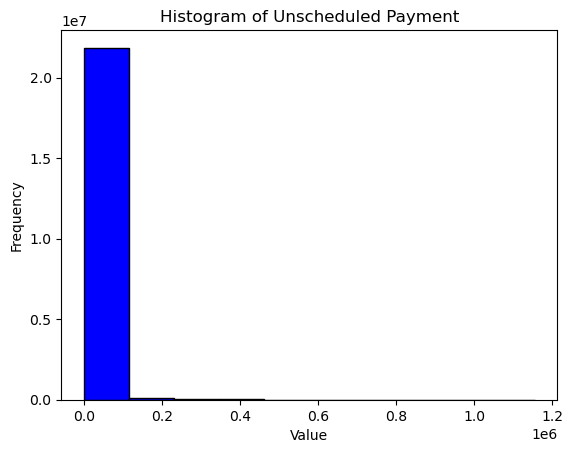

In [28]:
plt.hist(Q1_2015['Unscheduled Payment'], color='blue', edgecolor='black')  # bins 是柱子的数量
plt.title('Histogram of Unscheduled Payment')  # 图表标题
plt.xlabel('Value')  # x 轴标签
plt.ylabel('Frequency')  # y 轴标签
plt.show()

Calculate rate incentive: the current rate in Q1_2015 is incorrect, so we employ the rate in Macroecon dataframe

In [30]:
Q1_2015['Rate Incentive'] =Q1_2015['Original Interest Rate']  - Q1_2015['rate_lag2']

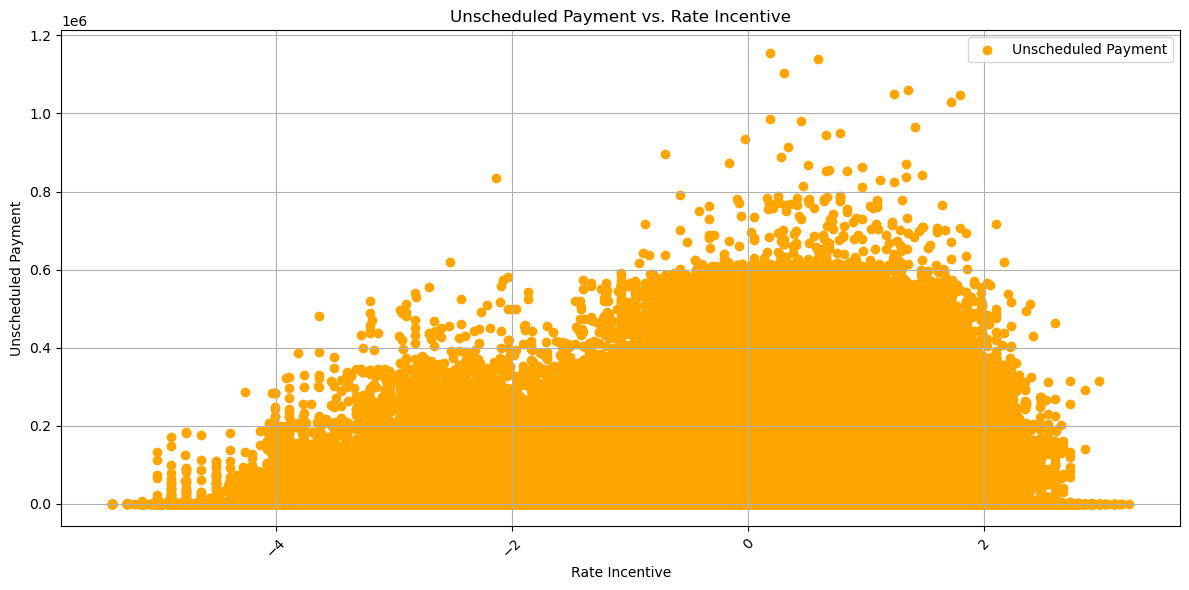

In [31]:
x = Q1_2015['Rate Incentive']

# 使用 'Unscheduled Payment' 作为 y 轴
y = Q1_2015['Unscheduled Payment']

# 创建折线图
plt.figure(figsize=(12, 6))  # 设置图形大小
plt.scatter(x, y, label='Unscheduled Payment', color='orange', marker='o')  # 绘制折线图

# 添加标题和标签
plt.title('Unscheduled Payment vs. Rate Incentive')
plt.xlabel('Rate Incentive')
plt.ylabel('Unscheduled Payment')
plt.xticks(rotation=45)  # 旋转 x 轴标签
plt.legend()  # 添加图例
plt.grid()  # 添加网格
plt.tight_layout()  # 自适应布局

# 显示图形
plt.show()

Calculate SMM

In [33]:
Q1_2015['SMM'] = Q1_2015['Unscheduled Payment']/(Q1_2015['Current Actual UPB']+Q1_2015['Payment'])
Q1_2015

,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,U.S. 30 yr FRM,rate_lag2,Monthly Interest Rate,Scheduled Payment,Interest Payment,Scheduled Principal,Payment,Unscheduled Payment,Rate Incentive,SMM
0,100002091588,2016-02-01,4.125,4.125,345000.0,338525.06,360,122014,22015,13.0,...,3.72,3.93,0.003438,1672.041577,1163.679894,508.361683,508.25,0.000000,0.195,0.000000
1,100002091588,2016-03-01,4.125,4.125,345000.0,338016.81,360,122014,22015,14.0,...,3.64,3.97,0.003438,1672.041577,1161.932784,510.108793,510.00,0.000000,0.155,0.000000
2,100002091588,2016-04-01,4.125,4.125,345000.0,337506.81,360,122014,22015,15.0,...,3.59,3.72,0.003438,1672.041577,1160.179659,511.861918,604.80,92.938082,0.405,0.000275
3,100002091588,2016-05-01,4.125,4.125,345000.0,336902.01,360,122014,22015,16.0,...,3.61,3.64,0.003438,1672.041577,1158.100659,513.940918,606.88,92.939082,0.485,0.000275
4,100002091588,2016-06-01,4.125,4.125,345000.0,336295.13,360,122014,22015,17.0,...,3.66,3.59,0.003438,1672.041577,1156.014509,516.027068,515.92,0.000000,0.535,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22509276,999995696635,2017-02-01,4.500,4.500,150000.0,143835.36,360,12015,32015,24.0,...,4.19,4.08,0.003750,760.027965,539.382600,220.645365,218.11,0.000000,0.420,0.000000
22509277,999995696635,2017-03-01,4.500,4.500,150000.0,143617.25,360,12015,32015,25.0,...,4.10,4.20,0.003750,760.027965,538.564687,221.463277,0.00,0.000000,0.300,0.000000
22509278,999995696635,2017-04-01,4.500,4.500,150000.0,143617.25,360,12015,32015,26.0,...,4.10,4.19,0.003750,760.027965,538.564687,221.463277,438.68,217.216723,0.310,0.001508
22509279,999995696635,2017-05-01,4.500,4.500,150000.0,143178.57,360,12015,32015,27.0,...,4.02,4.10,0.003750,760.027965,536.919638,223.108327,143178.57,142955.461673,0.400,0.499221


## Processing 2019Q1 data

In [35]:
Q1_2019 = Q1_2019_0.apply(pd.to_numeric, errors='coerce')
Q1_2019['Monthly Reporting Period'] = pd.to_datetime(Q1_2019['Monthly Reporting Period'].astype(int).astype(str).str[-4:] + '-' + Q1_2019['Monthly Reporting Period'].astype(int).astype(str).str[0] + '-01')

Q1_2019 = pd.merge(Q1_2019, monthlyrate, left_on='Monthly Reporting Period', right_on=monthlyrate.columns[0], how='left')

# Calculate monthly rate with original rate, for scheduled interest calculating
Q1_2019['Monthly Interest Rate'] = Q1_2019['Original Interest Rate'] / 12 / 100

# Employ Amortization formula to calculate schedule
Q1_2019['Scheduled Payment'] = (Q1_2019['Original UPB'] *
                                (Q1_2019['Monthly Interest Rate'] * (1 + Q1_2019['Monthly Interest Rate']) ** Q1_2019['Original Loan Term']) /
                                ((1 + Q1_2019['Monthly Interest Rate']) ** Q1_2019['Original Loan Term'] - 1))

Q1_2019['Interest Payment'] = Q1_2019['Current Actual UPB'] * Q1_2019['Monthly Interest Rate']
Q1_2019['Scheduled Principal'] = Q1_2019['Scheduled Payment'] - Q1_2019['Interest Payment']

# 删除每个 Loan Identifier 的前 12 行
Q1_2019 = Q1_2019.groupby('Loan Identifier').apply(lambda x: x.iloc[12:]).reset_index(drop=True)

Q1_2019['Payment'] = Q1_2019.groupby('Loan Identifier')['Current Actual UPB'].transform(lambda x: x - x.shift(-1))

Q1_2019['Unscheduled Payment'] = (Q1_2019['Payment'] - Q1_2019['Scheduled Principal']).clip(lower=0)
Q1_2019['Rate Incentive'] = Q1_2019['Original Interest Rate'] - Q1_2019['rate_lag2']
Q1_2019['SMM'] = Q1_2019['Unscheduled Payment'] / (Q1_2019['Current Actual UPB'] + Q1_2019['Payment'])

Q1_2019

C:\Users\cj dong\AppData\Local\Temp\ipykernel_1192\1993618834.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Q1_2019 = Q1_2019.groupby('Loan Identifier').apply(lambda x: x.iloc[12:]).reset_index(drop=True)


,Loan Identifier,Monthly Reporting Period,Original Interest Rate,Current Interest Rate,Original UPB,Current Actual UPB,Original Loan Term,Origination Date,First Payment Date,Loan Age,...,U.S. 30 yr FRM,rate_lag2,Monthly Interest Rate,Scheduled Payment,Interest Payment,Scheduled Principal,Payment,Unscheduled Payment,Rate Incentive,SMM
0,100000913397,2020-02-01,5.875,5.875,324000.0,318516.14,360,92018,112018,16.0,...,3.45,3.68,0.004896,1916.582353,1559.401935,357.180417,318516.14,318158.959583,2.195,0.499439
1,100000913397,2020-03-01,5.875,NaN,324000.0,0.00,360,92018,112018,NaN,...,3.29,3.72,0.004896,1916.582353,0.000000,1916.582353,NaN,NaN,2.155,NaN
2,100017539727,2020-02-01,4.750,NaN,307000.0,0.00,360,122018,22019,NaN,...,3.45,3.68,0.003958,1601.457323,0.000000,1601.457323,NaN,NaN,1.070,NaN
3,100018053040,2020-01-01,4.875,4.875,256000.0,252297.59,360,112018,12019,13.0,...,3.72,3.69,0.004063,1354.773053,1024.958959,329.814094,332.45,2.635906,1.185,0.000010
4,100018053040,2020-02-01,4.875,4.875,256000.0,251965.14,360,112018,12019,14.0,...,3.45,3.68,0.004063,1354.773053,1023.608381,331.164672,333.80,2.635328,1.195,0.000010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6272723,999997761057,2020-05-01,5.750,5.750,75000.0,73834.35,360,122018,22019,16.0,...,3.26,3.29,0.004792,437.679642,353.789594,83.890049,0.00,0.000000,2.460,0.000000
6272724,999997761057,2020-06-01,5.750,5.750,75000.0,73834.35,360,122018,22019,17.0,...,3.18,3.33,0.004792,437.679642,353.789594,83.890049,0.00,0.000000,2.420,0.000000
6272725,999997761057,2020-07-01,5.750,5.750,75000.0,73834.35,360,122018,22019,18.0,...,3.07,3.26,0.004792,437.679642,353.789594,83.890049,0.00,0.000000,2.490,0.000000
6272726,999997761057,2020-08-01,5.750,5.750,75000.0,73834.35,360,122018,22019,19.0,...,2.88,3.18,0.004792,437.679642,353.789594,83.890049,73834.35,73750.459951,2.570,0.499432


### Drawing S Curve

In [37]:
Q1_2015.columns

Index(['Loan Identifier', 'Monthly Reporting Period', 'Original Interest Rate',
       'Current Interest Rate', 'Original UPB', 'Current Actual UPB',
       'Original Loan Term', 'Origination Date', 'First Payment Date',
       'Loan Age', 'Remaining Months to Legal Maturity',
       'Remaining Months To Maturity', 'Original LTV', 'Debt-To-Income (DTI)',
       'FICO at Origination', 'Loan Purpose', 'Occupancy Status',
       'Property State', 'Date', 'U.S. 30 yr FRM', 'rate_lag2',
       'Monthly Interest Rate', 'Scheduled Payment', 'Interest Payment',
       'Scheduled Principal', 'Payment', 'Unscheduled Payment',
       'Rate Incentive', 'SMM'],
      dtype='object')

In [38]:
buckets = ['FICO at Origination',            # FICO
    'Original UPB',                   # 原始贷款余额
    'Occupancy Status',               # 占用类型
    'Loan Purpose',                   # 贷款目的
    'Debt-To-Income (DTI)',           # DTI
    'Property State'                   # 地理位置
]

In [39]:
import seaborn as sns

def draw_SCurve(df, bucket=0,label=0,b):
    bucket_group = bucket+' Group'
    
    data = df.copy()
    data[bucket_group] = pd.cut(data[bucket], 
                                 bins = b,
                               labels = label)
    # 创建 Rate Incentive 范围
    data['Incentive Group'] = pd.cut(data['Rate Incentive'], 
                                      bins= [-float('inf'), -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, float('inf')], 
                                      labels = ['<-100 bps', '-100 to -50 bps', '-50 to 0 bps', '0 to 50 bps', '50 to 100 bps', '100 to 150 bps', '>150 bps'])
    # 计算每个 FICO 组和 Incentive 组的平均 SMM
    avg_smm = data.groupby([bucket_group, 'Incentive Group'])['SMM'].mean().reset_index()
    # 绘图
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=avg_smm, x='Incentive Group', y='SMM', hue=bucket_group, marker='o')
    
    # 添加图表细节
    plt.title(bucket)
    plt.xlabel('Incentive')
    plt.ylabel('Average SMM')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)  # 旋转 X 轴标签以便更清晰
    plt.show()

draw_SCurve(Q1_2015,'FICO at Origination',label = ['FICO700-', 'FICO700-760', 'FICO760+'],b = [0, 700, 760, float('inf')])
draw_SCurve(Q1_2019,'FICO at Origination',label = ['FICO700-', 'FICO700-760', 'FICO760+'],b = [0, 700, 760, float('inf')])

SyntaxError: parameter without a default follows parameter with a default (1864549733.py, line 3)

In [ ]:
draw_SCurve(Q1_2015,'Original UPB',b = [50000, 100000, 150000, 200000, 300000, 400000, 500000, float('inf')],label = ['50K', '100K', '150K', '200K', '300K', '400K', '500K+'])
draw_SCurve(Q1_2019,'Original UPB',b = [50000, 100000, 150000, 200000, 300000, 400000, 500000, float('inf')],label = ['50K', '100K', '150K', '200K', '300K', '400K', '500K+'])

In [ ]:
draw_SCurve(Q1_2015,'Debt-To-Income (DTI)',b=[0,20,30,40,52],label=['<20','20~30','30~40','>40'])
draw_SCurve(Q1_2019,'Debt-To-Income (DTI)',b=[0,20,30,40,52],label=['<20','20~30','30~40','>40'])

In [ ]:
def draw_SCurve_descrete(bucket,Q1_2015 = Q1_2015):
    label = list(Q1_2015[bucket].unique())
    bucket_group = bucket + ' Group'
    
    data = Q1_2015.copy()
    
    # 假设 data[bucket] 是离散分类数据，例如 'P', 'S', 'I'
    # 直接使用这些分类数据作为分组，无需 pd.cut
    data[bucket_group] = data[bucket]
    
    # 创建 Rate Incentive 范围
    data['Incentive Group'] = pd.cut(data['Rate Incentive'], 
                                      bins= [-float('inf'), -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, float('inf')], 
                                      labels = ['<-100 bps', '-100 to -50 bps', '-50 to 0 bps', '0 to 50 bps', '50 to 100 bps', '100 to 150 bps', '>150 bps'])
    
    # 计算每个分类组和 Incentive 组的平均 SMM
    avg_smm = data.groupby([bucket_group, 'Incentive Group'])['SMM'].mean().reset_index()
    
    # 绘图
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=avg_smm, x='Incentive Group', y='SMM', hue=bucket_group, marker='o')
    
    # 添加图表细节
    plt.title(bucket)
    plt.xlabel('Incentive')
    plt.ylabel('Average SMM')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)  # 旋转 X 轴标签以便更清晰
    plt.show()

### Add-in: Replace states other than NY, FL, TX to 'other', due to our need

In [ ]:
Q1_2015['Property State']

In [ ]:
Q1_2019['Property State'] = Q1_2019['Property State'].replace(
    to_replace=[x for x in Q1_2019['Property State'].unique() if x not in ['NY', 'FL', 'TX']],
    value='other'
)
# So do 2015Q1
Q1_2015['Property State'] = Q1_2015['Property State'].replace(
    to_replace=[x for x in Q1_2015['Property State'].unique() if x not in ['NY', 'FL', 'TX']],
    value='other'
)

done, let's continue

In [ ]:
data = Q1_2015.head(10000)
bucket='Property State'
bucket_group = bucket + ' Group'
data[bucket_group] = data[bucket]
    
    # 创建 Rate Incentive 范围
data['Incentive Group'] = pd.cut(data['Rate Incentive'],
                                 bins= [-float('inf'), -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, float('inf')], 
                                 labels = ['<-100 bps', '-100 to -50 bps', '-50 to 0 bps', '0 to 50 bps', '50 to 100 bps', '100 to 150 bps', '>150 bps'])
    
    # 计算每个分类组和 Incentive 组的平均 SMM
avg_smm = data.groupby([bucket_group, 'Incentive Group'])['SMM'].mean().reset_index()
    
    # 绘图
plt.figure(figsize=(12, 8))
sns.lineplot(data=avg_smm, x='Incentive Group', y='SMM', hue=bucket_group, marker='o')

In [ ]:
draw_SCurve_descrete('Loan Purpose')

In [ ]:
draw_SCurve_descrete('Occupancy Type')

In [ ]:
draw_SCurve_descrete('Property State')

# Turn Over
❑ There are several data sources, the Federal Reserve of Saint Loius’s FRED 
database or Bloomberg  
❑ For the sake of simplicity, one can assume ~6% CPR or 0.51% SMM  
❑ Create an upward sloping ramp to 6CPR by month 30and flat for the 
remainder  
❑ Adjust each month’s ramp based on month in year based on following table

In [ ]:
monthly_ramp_example = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "July", "Aug", "Sept", "Oct", "Nov", "Dec"],
    "Seasonality": [0.87, 0.86, 0.87, 0.93, 1.00, 1.08, 1.13, 1.15, 1.12, 1.07, 0.99, 0.91]
})
monthly_ramp_example.set_index("Month", inplace=True)
print(monthly_ramp_example)

In [ ]:
target_cpr = 6.0  # target CPR in percentage
months = np.arange(1, 61)  # Months from 1 to 60 (5 years)

# Create a seasonality series for 60 months (5 years)
seasonality_series = np.tile(monthly_ramp_example['Seasonality'].values, 5)

# Create the ramp values
ramp = np.linspace(0, target_cpr, 30)  # Ramp from 0% to 6% over 30 months
flat_ramp = np.full(30, target_cpr)    # Flat line for months 31 to 60

# Combine the ramps
full_ramp = np.concatenate((ramp, flat_ramp))

# Adjust the ramp based on seasonality
adjusted_ramp = full_ramp * (seasonality_series / 100)  # Adjusting for seasonality

# Generate month names from January 2015 to December 2019
start_date = pd.to_datetime("2015-01-01")
month_names = [start_date + pd.DateOffset(months=i) for i in range(60)]
month_names = [d.strftime("%b %Y") for d in month_names]  # Format to "Jan 2015", etc.

# Create a DataFrame to hold the results
result = pd.DataFrame({
    "Month": month_names,
    "Adjusted CPR": adjusted_ramp
})

# Print the resulting DataFrame
print(result.head())

plt.figure(figsize=(12, 6))
plt.plot(result['Month'], result['Adjusted CPR'], marker='o', linestyle='-', color='blue')
plt.title('Adjusted CPR from Jan 2015 to Dec 2019')
plt.xlabel('Month')
plt.ylabel('Adjusted CPR (%)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

## Lock-in effect

# Curtailment
❑ Partial Prepayments, also known as Curtailments, are extra payments of principal beyond scheduled principal.  
❑ Monthly payment due on a level payment mortgage is fixed, when a borrower sends in a larger monthly payment than   
the one due, the borrower is effectively shortening the remaining term of the mortgage.  
❑ For simplicity, we will use the following function to by loan age ‘t’

In [ ]:
def Curtailment_CPR(t):
    if 0 <= t <= 15:
        return (1/5) * t
    elif 15 < t <= 20:
        return (6/5) * (t - 15) + 3
    elif 20 < t <= 25:
        return (3/5) * (t - 20) + 9
    elif 25 < t <= 30:
        return 2 * (t - 15) + 12
    elif 30 < t <= 70:
        return 22
    else:
        return "t is out of range"

# example
print(Curtailment_CPR(10))